# 04 -- Object Detection (lightweight trainable detector)

Fourth and last notebook in the pipeline (see `01_data_preparation.ipynb` for the full layout).
Loads the preprocessed 512x512 images/masks cached by `02_eda_and_preprocessing.ipynb`.

Covers:
- **Step 5**: derive ground-truth bounding boxes from the lung masks, fine-tune a small YOLO26n
  detector on them, and build a second, classical alternative (PCA + SVM sliding window) for
  comparison
- **Step 6 (detection half)**: IoU-based precision/recall and mAP@0.5 on the held-out test split
  for both detectors
- **Step 7 (last piece)**: each detector's loss/objective function

Unlike Step 4's classical segmentation methods, both detectors here are explicitly meant to be
**trainable, not heuristic** -- box locations are learned from the training split, nothing about
where lungs typically sit in the frame is hardcoded.

In [1]:
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"  # GPU if available, CPU fallback otherwise
print(f"Using device: {DEVICE}" + ("" if DEVICE == 'cpu' else f" ({torch.cuda.get_device_name(0)})"))

DATA_DIR = Path("../data")
PROC_IMG_DIR = DATA_DIR / "processed" / "images"
PROC_MASK_DIR = DATA_DIR / "processed" / "masks"
TARGET_SIZE = 512

assert (DATA_DIR / "manifest.csv").exists(), "Run 01_data_preparation.ipynb first to generate data/manifest.csv"
assert PROC_IMG_DIR.exists(), "Run 02_eda_and_preprocessing.ipynb first to generate data/processed/"

manifest = pd.read_csv(DATA_DIR / "manifest.csv")

_HOME = str(Path.home())
def anon(path) -> str:
    # mask the local home directory before printing/displaying (notebook is shared publicly)
    return str(path).replace(_HOME, "<USER>")

def load_processed(id_):
    img = np.array(Image.open(PROC_IMG_DIR / f"{id_}.png"))
    mask = np.array(Image.open(PROC_MASK_DIR / f"{id_}.png"))
    return img, mask

Using device: 0 (NVIDIA GeForce RTX 5070 Ti)


## Step 5.1 -- Ground-truth boxes from masks (connected components)

Each mask's connected components are found with 8-connectivity; each component's axis-aligned
bounding box becomes one ground-truth detection box. We keep at most the **2 largest** components
by pixel area (the two lungs) and drop anything under 0.5% of the image area (noise-sized specks --
a safety net, not something these clean hand-annotated masks are expected to need).

This is entirely intensity/shape-driven (component size ranking), not a spatial assumption about
where lungs are positioned -- satisfying the assignment's "no hardcoded box-finding rules"
constraint (that constraint is specifically about the detector, not Step 4's classical methods).

In [2]:
def boxes_from_mask(mask, min_area_frac=0.005, max_boxes=2):
    h, w = mask.shape
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 127).astype(np.uint8), connectivity=8)
    comps = [stats[lbl] for lbl in range(1, n_labels) if stats[lbl][4] >= min_area_frac * h * w]
    comps.sort(key=lambda s: -s[4])  # sort by area, descending
    comps = comps[:max_boxes]
    return [(x, y, x + bw, y + bh) for x, y, bw, bh, _area in comps]  # (x1, y1, x2, y2)

# sanity check across the whole labeled set: how many raw components does each mask actually have?
raw_counts, all_boxes = [], {}
for r in manifest.itertuples():
    _, mask = load_processed(r.id)
    n_labels, _, _, _ = cv2.connectedComponentsWithStats((mask > 127).astype(np.uint8), connectivity=8)
    raw_counts.append(n_labels - 1)
    all_boxes[r.id] = boxes_from_mask(mask)

manifest["raw_components"] = raw_counts
manifest["kept_boxes"] = manifest["id"].map(lambda i: len(all_boxes[i]))
print("Raw connected-component count per mask:")
print(manifest["raw_components"].value_counts().sort_index())
print("\nBoxes kept per image after area filtering:")
print(manifest["kept_boxes"].value_counts().sort_index())

Raw connected-component count per mask:
raw_components
2    654
3     39
4      9
5      1
7      1
Name: count, dtype: int64

Boxes kept per image after area filtering:
kept_boxes
2    704
Name: count, dtype: int64


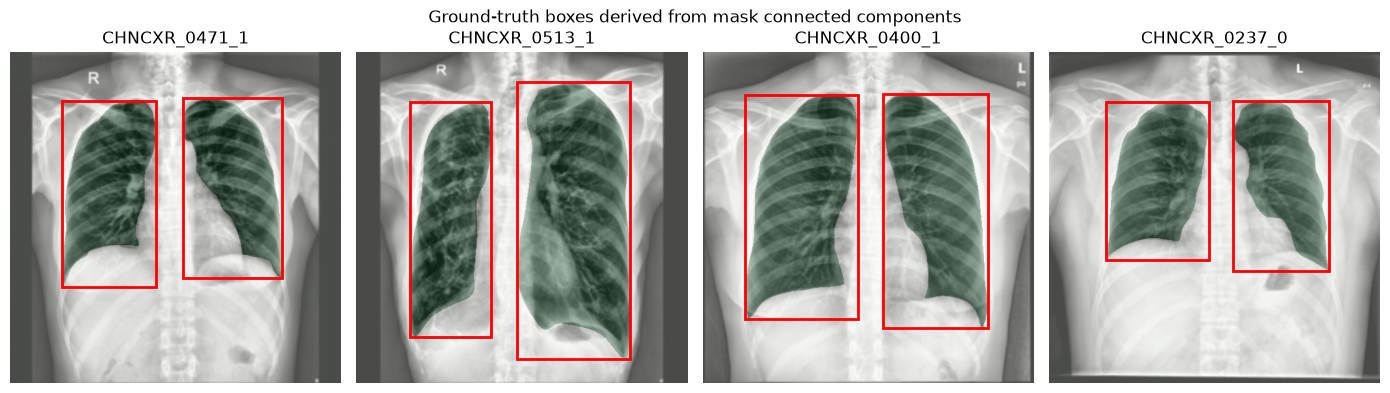

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, id_ in zip(axes, manifest["id"].sample(4, random_state=1)):
    img, mask = load_processed(id_)
    ax.imshow(img, cmap="gray")
    ax.imshow(mask, cmap="Greens", alpha=0.3)
    for (x1, y1, x2, y2) in all_boxes[id_]:
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="red", facecolor="none", lw=2))
    ax.set_title(id_); ax.axis("off")
fig.suptitle("Ground-truth boxes derived from mask connected components")
fig.tight_layout(); plt.show()

## Step 5.2 -- Build a YOLO-format dataset

Ultralytics expects `images/<split>/*.png` next to `labels/<split>/*.txt`, one label line per box:
`<class> <x_center> <y_center> <width> <height>`, all normalized to `[0,1]`. Single class (`lung`,
id 0) -- we're not distinguishing left/right, just detecting lung regions. We copy the already
size-normalized 512x512 processed PNGs rather than re-deriving anything from the raw originals.

In [4]:
YOLO_DIR = DATA_DIR / "yolo_dataset"
for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

for r in manifest.itertuples():
    shutil.copyfile(PROC_IMG_DIR / f"{r.id}.png", YOLO_DIR / "images" / r.split / f"{r.id}.png")
    lines = []
    for (x1, y1, x2, y2) in all_boxes[r.id]:
        xc, yc = (x1 + x2) / 2 / TARGET_SIZE, (y1 + y2) / 2 / TARGET_SIZE
        bw, bh = (x2 - x1) / TARGET_SIZE, (y2 - y1) / TARGET_SIZE
        lines.append(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    (YOLO_DIR / "labels" / r.split / f"{r.id}.txt").write_text("\n".join(lines))

data_yaml_path = YOLO_DIR / "data.yaml"
data_yaml_path.write_text(
    f"path: {YOLO_DIR.resolve()}\ntrain: images/train\nval: images/val\ntest: images/test\nnames:\n  0: lung\n"
)
print("Wrote YOLO dataset ->", anon(YOLO_DIR))
print(f"train/val/test images: "
      f"{len(list((YOLO_DIR/'images/train').glob('*.png')))}/"
      f"{len(list((YOLO_DIR/'images/val').glob('*.png')))}/"
      f"{len(list((YOLO_DIR/'images/test').glob('*.png')))}")

Wrote YOLO dataset -> ..\data\yolo_dataset
train/val/test images: 492/106/106


## Step 5.3 -- Fine-tune YOLO26n

Small model, short training (a handful of epochs), single class -- per the assignment's "runnable
in class time on one GPU session" constraint. We start from COCO-pretrained weights (transfer
learning) rather than training from scratch, which is standard practice and lets a tiny dataset
(492 training images) still produce a usable detector.

**YOLO26n rather than YOLOv8n:** YOLO26 is the more recent generation available in our installed
`ultralytics` package (verified directly against the installed package's model configs, not
assumed) -- its nano variant is even smaller than YOLOv8n's (2.57M vs. ~3M parameters) while being
architecturally newer. It's also end-to-end / NMS-free by design (`end2end: True` in its config),
which changes its loss slightly from YOLOv8's -- documented accurately in Step 7 below rather than
reusing the YOLOv8 writeup unchanged.

In [5]:
from ultralytics import YOLO

RUNS_DIR = (DATA_DIR / ".." / "runs").resolve()  # absolute, so it always lands at the repo root
RUN_NAME = "lung_yolo26n"
weights_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"

# Skip re-training if we already have a checkpoint from a previous run of this notebook -- training
# takes real GPU time, and re-running it every time this notebook is re-executed (e.g. to add an
# analysis cell downstream) is wasteful. Delete the run directory to force a fresh training run.
if weights_path.exists():
    print(f"Found existing trained weights at {anon(weights_path)} -- loading instead of retraining.")
    model = YOLO(str(weights_path))
else:
    model = YOLO("yolo26n.pt")
    train_results = model.train(
        data=str(data_yaml_path),
        epochs=30,
        imgsz=TARGET_SIZE,
        batch=16,
        device=DEVICE,
        project=str(RUNS_DIR),
        name=RUN_NAME,
        seed=42,
        patience=10,
        verbose=True,
    )

Found existing trained weights at <USER>\.dev\cva_cxr\runs\lung_yolo26n\weights\best.pt -- loading instead of retraining.


## Step 7 -- Detector loss function (YOLO26n)

Checked directly against the installed `ultralytics` source (`ultralytics/utils/loss.py`) rather
than assumed from the YOLOv8 formulation, since YOLO26 turns out to differ in two real ways:

$$\mathcal{L} = \lambda_{box}\,\mathcal{L}_{CIoU} + \lambda_{dfl}\,\mathcal{L}_{box\text{-}edge} + \lambda_{cls}\,\mathcal{L}_{BCE}$$

- **$\mathcal{L}_{CIoU}$ (box regression)** -- Complete-IoU loss, same as YOLOv8: extends plain IoU
  loss with penalty terms for center-point distance and aspect-ratio mismatch (Zheng et al.,
  *"Distance-IoU Loss"*, AAAI 2020).
- **$\mathcal{L}_{box\text{-}edge}$ -- plain L1, not DFL.** YOLOv8 models each box edge as a
  discrete probability distribution over `reg_max=16` bins (Distribution Focal Loss). YOLO26n's
  config sets `reg_max: 1`, which the loss code (`BboxLoss`, `self.dfl_loss = DFLoss(reg_max) if
  reg_max > 1 else None`) uses as a switch to fall back to a direct **L1 loss** on the normalized
  box-edge distances instead. Simpler, fewer parameters in the detection head, at the cost of the
  finer-grained localization DFL's soft binning can give.
- **$\mathcal{L}_{BCE}$ (classification)** -- binary cross-entropy per class per grid cell,
  unchanged from YOLOv8; single class here (lung).

**Also new: dual one-to-many / one-to-one assignment.** Because YOLO26 is configured
`end2end: True`, training runs two parallel copies of the loss above (`E2EDetectLoss` in the
source) -- a "one-to-many" branch using the usual top-10 task-aligned assignment (rich supervision
signal, same as YOLOv8) and a "one-to-one" branch matching exactly one prediction per ground-truth
box. The one-to-one branch is what lets the model skip NMS entirely at inference (it's trained to
already emit one confident box per object). This dual-assignment idea originates with YOLOv10 (Wang
et al., *"YOLOv10: Real-Time End-to-End Object Detection"*, 2024), which YOLO26 carries forward.

Reference: Ultralytics YOLO26 docs (https://docs.ultralytics.com/models/yolo26); source inspected
directly at `ultralytics/utils/loss.py` (`BboxLoss`, `v8DetectionLoss`, `E2EDetectLoss`) in the
installed package. No derivation needed here -- stated and cited per the assignment's instructions
for this section.

## Step 6 (detection) -- Benchmarking

First, Ultralytics' own built-in validator on the held-out **test split** (never seen during
training) -- gives mAP@0.5, mAP@0.5:0.95, precision and recall directly.

In [6]:
metrics = model.val(data=str(data_yaml_path), split="test", imgsz=TARGET_SIZE, device=DEVICE)
print(f"mAP@0.5:      {metrics.box.map50:.3f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.3f}")
print(f"Precision:    {metrics.box.mp:.3f}")
print(f"Recall:       {metrics.box.mr:.3f}")

Ultralytics 8.4.156  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)


YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs


WARNING val: Slow image access detected (ping: 0.00.0 ms, read: 25.13.1 MB/s, size: 103.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips


val: Scanning C:\Users\Miko\.dev\cva_cxr\data\yolo_dataset\labels\test.cache... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 1/7 6.4s/it 1.9s<38.4s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.8it/s 2.5s

                   all        106        212          1          1      0.995      0.927


Speed: 0.8ms preprocess, 1.5ms inference, 0.0ms loss, 1.4ms postprocess per image


Results saved to C:\Users\Miko\.dev\cva_cxr\notebooks\runs\detect\val


mAP@0.5:      0.995
mAP@0.5:0.95: 0.927
Precision:    1.000
Recall:       1.000


### Manual IoU-matched precision/recall

A from-scratch computation alongside Ultralytics' own metric, so the number isn't just taken on
faith: greedily match each predicted box to the highest-IoU unmatched ground-truth box, count it a
true positive if that IoU is >= 0.5.

In [7]:
def iou_xyxy(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    area2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def match_boxes(gt_boxes, pred_boxes, iou_thresh=0.5):
    matched_gt, tp, ious = set(), 0, []
    for pb in pred_boxes:
        best_iou, best_j = 0.0, -1
        for j, gb in enumerate(gt_boxes):
            if j in matched_gt:
                continue
            i = iou_xyxy(pb, gb)
            if i > best_iou:
                best_iou, best_j = i, j
        if best_iou >= iou_thresh:
            tp += 1; matched_gt.add(best_j); ious.append(best_iou)
    return tp, len(pred_boxes) - tp, len(gt_boxes) - len(matched_gt), ious

test_df = manifest[manifest.split == "test"]
test_paths = [str(YOLO_DIR / "images" / "test" / f"{id_}.png") for id_ in test_df["id"]]
pred_results = model.predict(test_paths, imgsz=TARGET_SIZE, device=DEVICE, verbose=False)

totals = {"tp": 0, "fp": 0, "fn": 0}
all_ious, per_image_iou = [], {}
for id_, res in zip(test_df["id"], pred_results):
    pred_boxes = res.boxes.xyxy.cpu().numpy().tolist()
    gt_boxes = all_boxes[id_]
    tp, fp, fn, ious = match_boxes(gt_boxes, pred_boxes)
    totals["tp"] += tp; totals["fp"] += fp; totals["fn"] += fn
    all_ious.extend(ious)
    per_image_iou[id_] = np.mean(ious) if ious else 0.0

precision = totals["tp"] / (totals["tp"] + totals["fp"]) if (totals["tp"] + totals["fp"]) else 0.0
recall = totals["tp"] / (totals["tp"] + totals["fn"]) if (totals["tp"] + totals["fn"]) else 0.0
print(f"IoU>=0.5 matching over {len(test_df)} test images:")
print(f"  precision = {precision:.3f}   recall = {recall:.3f}   mean matched IoU = {np.mean(all_ious):.3f}")
print(f"  TP={totals['tp']}  FP={totals['fp']}  FN={totals['fn']}")

IoU>=0.5 matching over 106 test images:
  precision = 1.000   recall = 1.000   mean matched IoU = 0.948
  TP=212  FP=0  FN=0


### Qualitative comparison, including a failure case

Green = ground truth, red dashed = prediction. Last panel is the test image with the lowest mean
matched IoU -- the detector's worst case.

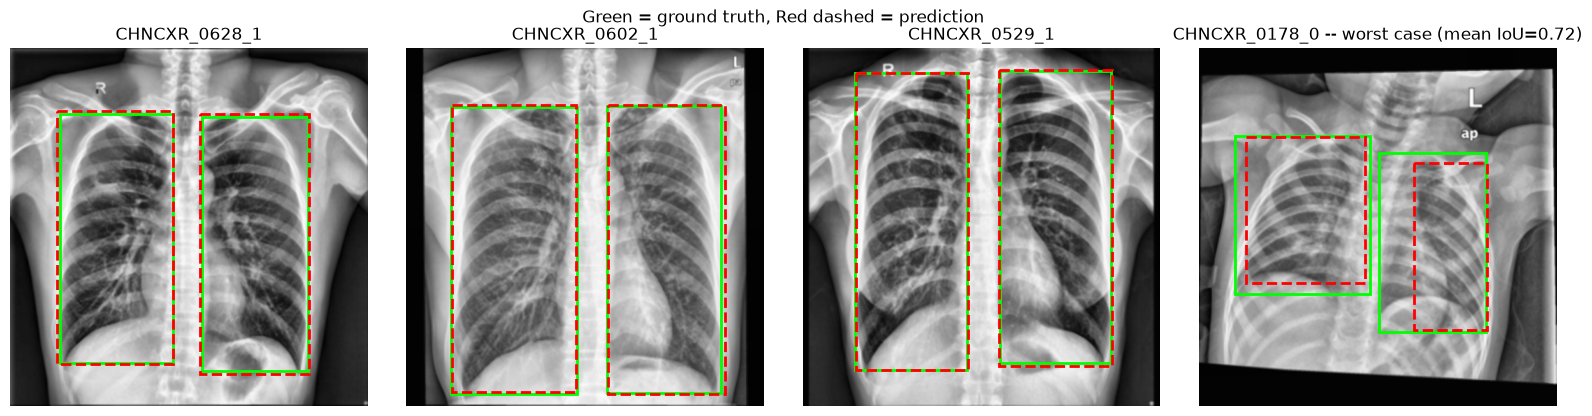

In [8]:
def show_pred(ax, id_, title=None):
    img = np.array(Image.open(YOLO_DIR / "images" / "test" / f"{id_}.png").convert("RGB"))
    ax.imshow(img)
    for (x1, y1, x2, y2) in all_boxes[id_]:
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="lime", facecolor="none", lw=2))
    res = pred_results[list(test_df["id"]).index(id_)]
    for (x1, y1, x2, y2) in res.boxes.xyxy.cpu().numpy():
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="red", facecolor="none", lw=2, linestyle="--"))
    ax.set_title(title or id_); ax.axis("off")

sample_ids = test_df["id"].sample(3, random_state=2).tolist()
worst_id = min(per_image_iou, key=per_image_iou.get)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, id_ in zip(axes[:3], sample_ids):
    show_pred(ax, id_)
show_pred(axes[3], worst_id, title=f"{worst_id} -- worst case (mean IoU={per_image_iou[worst_id]:.2f})")
fig.suptitle("Green = ground truth, Red dashed = prediction")
fig.tight_layout(); plt.show()

## Step 5 (alternative) -- PCA + SVM sliding-window detector

A second, classical-ML trainable detector to compare against YOLO26n: PCA for feature extraction,
a linear SVM for classification, sliding-window search at inference. Both stages are genuinely
*fit to the training split* (unlike Step 4's classical segmentation, which used fixed formulas with
no data-fitting at all) -- but the fitting is a one-shot closed-form projection (PCA) plus a convex
classifier (SVM), not gradient-based representation learning the way YOLO's backbone is trained.
That's the real distinction worth carrying into the comparison: both are "trained," but on very
different amounts of learned structure.

**Patch size, data-driven:** rather than picking a window size by eye, we take the median
width/height of the ground-truth boxes from Step 5.1's training-split boxes and use that directly
-- keeps the sliding window's aspect ratio consistent with what an actual lung box looks like.

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

def compute_letterbox(orig_w, orig_h, target=TARGET_SIZE):
    scale = target / max(orig_w, orig_h)
    new_w, new_h = int(round(orig_w * scale)), int(round(orig_h * scale))
    pad_w, pad_h = target - new_w, target - new_h
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2
    return top, bottom, left, right

def valid_region_mask(id_):
    with Image.open(manifest.set_index("id").loc[id_, "image_path"]) as im:
        w, h = im.size
    top, bottom, left, right = compute_letterbox(w, h)
    vmask = np.zeros((TARGET_SIZE, TARGET_SIZE), dtype=bool)
    vmask[top:TARGET_SIZE - bottom, left:TARGET_SIZE - right] = True
    return vmask

train_ids = manifest.loc[manifest.split == "train", "id"].tolist()
val_ids = manifest.loc[manifest.split == "val", "id"].tolist()

box_ws = [x2 - x1 for id_ in train_ids for (x1, y1, x2, y2) in all_boxes[id_]]
box_hs = [y2 - y1 for id_ in train_ids for (x1, y1, x2, y2) in all_boxes[id_]]
PATCH_W = int(round(np.median(box_ws) / 2)) * 2  # round to even for clean half-splitting
PATCH_H = int(round(np.median(box_hs) / 2)) * 2
print(f"Median GT box size (train split): {np.median(box_ws):.0f} x {np.median(box_hs):.0f} "
      f"-> sliding window size {PATCH_W} x {PATCH_H}")

Median GT box size (train split): 153 x 330 -> sliding window size 152 x 330


### Build the training patch dataset

Positive patches: centered on each ground-truth box. Negative patches: random locations (within
the valid, non-padded region) whose IoU with every ground-truth box in that image is below 0.1 --
i.e. genuinely background, not near-miss lung edges.

In [10]:
def extract_patch(img, cx, cy, w, h):
    half_w, half_h = w // 2, h // 2
    x1, y1 = cx - half_w, cy - half_h
    x2, y2 = x1 + w, y1 + h
    H, W = img.shape
    x1c, y1c, x2c, y2c = max(0, x1), max(0, y1), min(W, x2), min(H, y2)
    patch = np.zeros((h, w), dtype=img.dtype)
    patch[y1c - y1:y2c - y1, x1c - x1:x2c - x1] = img[y1c:y2c, x1c:x2c]
    return patch

def box_iou_xyxy(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1]); a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

def build_patch_dataset(ids, neg_per_image=4, seed=42):
    # NOTE: negative centers are drawn from the *whole* valid region, not a "fully in-bounds"
    # band -- PATCH_H covers 64% of the canvas, so requiring the window to stay entirely inside
    # the image collapses valid centers to a narrow strip that already overlaps the lungs, and
    # nearly every candidate gets rejected. extract_patch already zero-pads anything that falls
    # outside the image, so there's no need for that restriction.
    rng = np.random.default_rng(seed)
    X, y = [], []
    for id_ in ids:
        img, _ = load_processed(id_)
        vmask = valid_region_mask(id_)
        valid_ys, valid_xs = np.where(vmask)
        boxes = all_boxes[id_]
        for (x1, y1, x2, y2) in boxes:
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            X.append(extract_patch(img, cx, cy, PATCH_W, PATCH_H).flatten()); y.append(1)
        n_neg, attempts = 0, 0
        while n_neg < neg_per_image and attempts < 200:
            attempts += 1
            idx = rng.integers(0, len(valid_ys))
            cx, cy = int(valid_xs[idx]), int(valid_ys[idx])
            cand = (cx - PATCH_W // 2, cy - PATCH_H // 2, cx + PATCH_W // 2, cy + PATCH_H // 2)
            if all(box_iou_xyxy(cand, b) < 0.1 for b in boxes):
                X.append(extract_patch(img, cx, cy, PATCH_W, PATCH_H).flatten()); y.append(0)
                n_neg += 1
    return np.array(X, dtype=np.float32), np.array(y)

X_train, y_train = build_patch_dataset(train_ids)
X_val, y_val = build_patch_dataset(val_ids)
print(f"train patches: {len(y_train)} (pos={int(y_train.sum())}, neg={int((y_train==0).sum())})")
print(f"val patches:   {len(y_val)} (pos={int(y_val.sum())}, neg={int((y_val==0).sum())})")

train patches: 2952 (pos=984, neg=1968)
val patches:   636 (pos=212, neg=424)


### Fit PCA + linear SVM

Standardize pixel features, fit PCA on the training patches, then a linear SVM on the PCA-reduced
representation. Validation-set patch accuracy is a sanity check before moving on to full
sliding-window detection on images.

In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_p = pca.fit_transform(X_train_s)
X_val_p = pca.transform(X_val_s)
print(f"PCA({N_COMPONENTS}) explains {pca.explained_variance_ratio_.sum():.1%} of patch-pixel variance")

svm = LinearSVC(C=1.0, random_state=42, max_iter=10000, class_weight="balanced")
svm.fit(X_train_p, y_train)
print(f"Validation patch classification accuracy: {svm.score(X_val_p, y_val):.3f}")

PCA(50) explains 94.1% of patch-pixel variance
Validation patch classification accuracy: 0.994


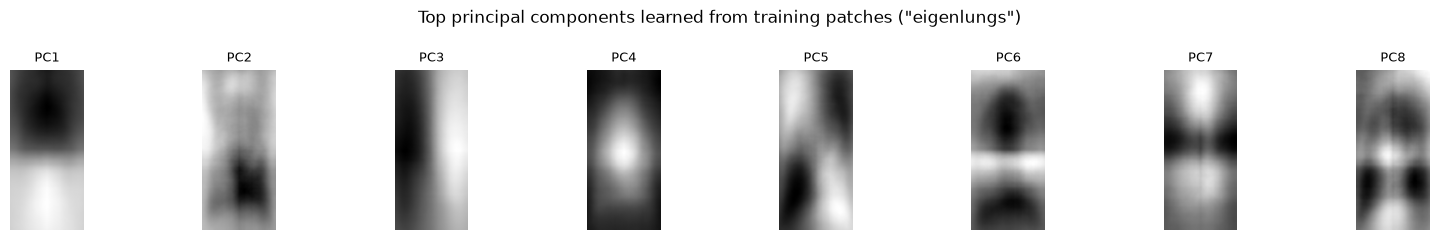

In [12]:
fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
for i, ax in enumerate(axes):
    ax.imshow(pca.components_[i].reshape(PATCH_H, PATCH_W), cmap="gray")
    ax.set_title(f"PC{i+1}", fontsize=9); ax.axis("off")
fig.suptitle('Top principal components learned from training patches ("eigenlungs")')
fig.tight_layout(); plt.show()

### Sliding-window detection at inference

Score every window on a grid (stride = 1/3 of the window size) within the valid region, batch all
patches through `scaler -> pca -> svm.decision_function` in one shot rather than one-by-one, keep
windows scoring above the SVM's own decision boundary (0.0), and greedily suppress overlaps
(IoU >= 0.3) down to at most 2 boxes per image, matching the two-lungs prior we already established
from the mask connected-components analysis in Step 5.1.

In [13]:
def sliding_window_detect(img, valid_mask, stride_frac=1/3, score_thresh=0.0, max_boxes=2, nms_iou=0.3):
    half_w, half_h = PATCH_W // 2, PATCH_H // 2
    stride_x, stride_y = max(1, int(PATCH_W * stride_frac)), max(1, int(PATCH_H * stride_frac))
    coords, patches = [], []
    for cy in range(0, TARGET_SIZE, stride_y):
        for cx in range(0, TARGET_SIZE, stride_x):
            if not valid_mask[cy, cx]:
                continue
            coords.append((cx, cy))
            patches.append(extract_patch(img, cx, cy, PATCH_W, PATCH_H).flatten())
    if not patches:
        return []
    scores = svm.decision_function(pca.transform(scaler.transform(np.array(patches, dtype=np.float32))))

    candidates = [
        (cx - half_w, cy - half_h, cx + half_w, cy + half_h, s)
        for (cx, cy), s in zip(coords, scores) if s > score_thresh
    ]
    candidates.sort(key=lambda c: -c[4])
    kept = []
    for c in candidates:
        if all(box_iou_xyxy(c[:4], k[:4]) < nms_iou for k in kept):
            kept.append(c)
        if len(kept) >= max_boxes:
            break
    return [c[:4] for c in kept]

svm_pred_boxes = {}
for id_ in test_df["id"]:
    img, _ = load_processed(id_)
    svm_pred_boxes[id_] = sliding_window_detect(img, valid_region_mask(id_))
print(f"Ran sliding-window detection on {len(svm_pred_boxes)} test images "
      f"(mean {np.mean([len(v) for v in svm_pred_boxes.values()]):.2f} boxes/image)")

Ran sliding-window detection on 106 test images (mean 2.00 boxes/image)


## Step 6 (SVM+PCA) -- Benchmarking, same protocol as YOLO26n

Same IoU>=0.5 greedy matching used for YOLO26n above, on the identical test split, for a fair
comparison.

**Why no mAP for this detector.** mAP needs a full precision-recall *curve*: sweep the confidence
threshold from strict to lenient, recompute precision/recall at every cutoff, integrate the area
underneath. YOLO gives this essentially out of the box -- Ultralytics' validator keeps every raw
candidate box with its confidence score internally and does that sweep for you. Our PCA+SVM
pipeline collapses straight to final answers instead: it scores every window, then immediately
applies one fixed threshold (the SVM's own decision boundary), runs NMS, and caps at 2 boxes --
discarding the score information a threshold sweep would need. What we report below (precision,
recall, mean matched IoU) is one point on that curve, not the curve itself. It's a fixable gap, not
a fundamental one -- the SVM's decision_function scores exist for every window before we threshold
them -- just not built here.

In [14]:
totals_svm = {"tp": 0, "fp": 0, "fn": 0}
all_ious_svm, per_image_iou_svm = [], {}
for id_ in test_df["id"]:
    tp, fp, fn, ious = match_boxes(all_boxes[id_], svm_pred_boxes[id_])
    totals_svm["tp"] += tp; totals_svm["fp"] += fp; totals_svm["fn"] += fn
    all_ious_svm.extend(ious)
    per_image_iou_svm[id_] = np.mean(ious) if ious else 0.0

precision_svm = totals_svm["tp"] / (totals_svm["tp"] + totals_svm["fp"]) if (totals_svm["tp"] + totals_svm["fp"]) else 0.0
recall_svm = totals_svm["tp"] / (totals_svm["tp"] + totals_svm["fn"]) if (totals_svm["tp"] + totals_svm["fn"]) else 0.0
print(f"SVM+PCA sliding window -- IoU>=0.5 matching over {len(test_df)} test images:")
print(f"  precision={precision_svm:.3f}  recall={recall_svm:.3f}  "
      f"mean matched IoU={np.mean(all_ious_svm) if all_ious_svm else float('nan'):.3f}")
print(f"  TP={totals_svm['tp']}  FP={totals_svm['fp']}  FN={totals_svm['fn']}")

SVM+PCA sliding window -- IoU>=0.5 matching over 106 test images:
  precision=0.830  recall=0.830  mean matched IoU=0.661
  TP=176  FP=36  FN=36


### Qualitative comparison, including a failure case

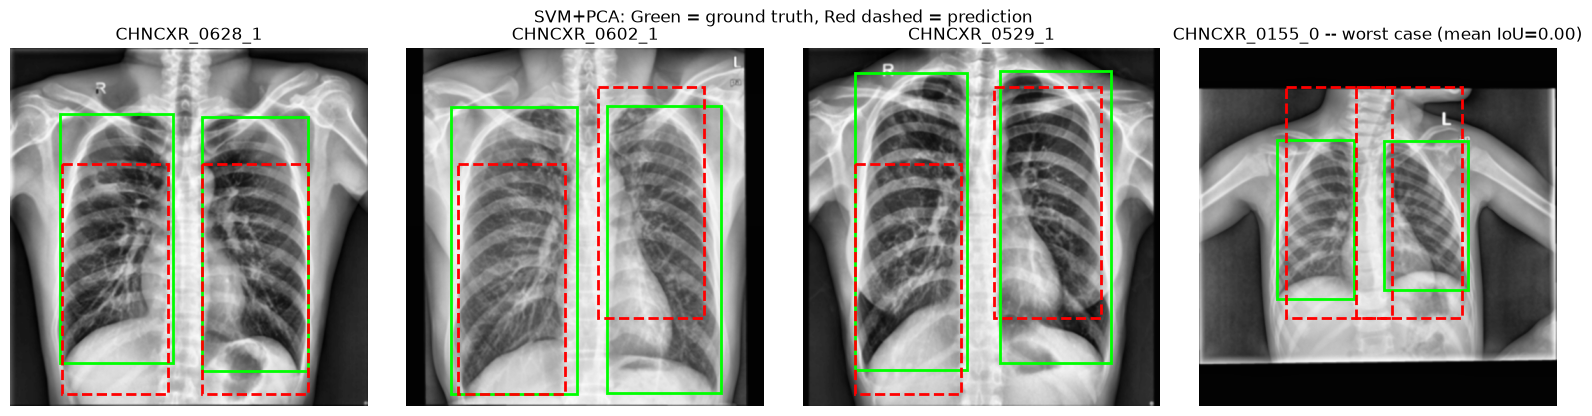

In [15]:
def show_svm_pred(ax, id_, title=None):
    img = np.array(Image.open(YOLO_DIR / "images" / "test" / f"{id_}.png").convert("RGB"))
    ax.imshow(img)
    for (x1, y1, x2, y2) in all_boxes[id_]:
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="lime", facecolor="none", lw=2))
    for (x1, y1, x2, y2) in svm_pred_boxes[id_]:
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="red", facecolor="none", lw=2, linestyle="--"))
    ax.set_title(title or id_); ax.axis("off")

sample_ids_svm = test_df["id"].sample(3, random_state=2).tolist()
worst_id_svm = min(per_image_iou_svm, key=per_image_iou_svm.get)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, id_ in zip(axes[:3], sample_ids_svm):
    show_svm_pred(ax, id_)
show_svm_pred(axes[3], worst_id_svm, title=f"{worst_id_svm} -- worst case (mean IoU={per_image_iou_svm[worst_id_svm]:.2f})")
fig.suptitle("SVM+PCA: Green = ground truth, Red dashed = prediction")
fig.tight_layout(); plt.show()

## Step 6 -- Final comparison: YOLO26n vs. PCA+SVM

**PCA+SVM's loss/objective (Step 7, for this detector):** a linear SVM minimizes **hinge loss**
plus an L2 margin penalty,

$$\min_{w,b} \ \tfrac{1}{2}\lVert w \rVert^2 + C \sum_i \max\big(0,\ 1 - y_i(w^\top x_i + b)\big)$$

where $x_i$ is a PCA-projected patch and $y_i \in \{-1, +1\}$ its pos/neg label (Cortes & Vapnik,
*"Support-Vector Networks"*, 1995). This is a **patch-classification** loss, not a box-regression
loss like YOLO's -- it never sees box coordinates directly, only "is this window a lung or not."
Localization quality here comes entirely from how finely the sliding-window grid samples positions,
not from anything being regressed.

,precision,recall,mean_matched_iou
detector,,,
YOLO26n,1.00,1.00,0.948
PCA+SVM (sliding window),0.83,0.83,0.661


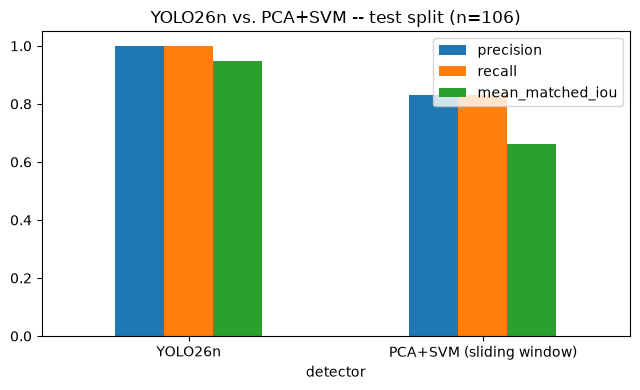

In [16]:
comparison = pd.DataFrame([
    {"detector": "YOLO26n", "precision": precision, "recall": recall, "mean_matched_iou": np.mean(all_ious)},
    {"detector": "PCA+SVM (sliding window)", "precision": precision_svm, "recall": recall_svm,
     "mean_matched_iou": np.mean(all_ious_svm) if all_ious_svm else np.nan},
]).set_index("detector")
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(6.5, 4))
comparison.plot.bar(ax=ax)
ax.set_ylim(0, 1.05); ax.set_title(f"YOLO26n vs. PCA+SVM -- test split (n={len(test_df)})")
plt.xticks(rotation=0)
fig.tight_layout(); plt.show()

## Overfitting check -- train vs. val vs. test, both detectors

Every number reported so far (mAP, precision, recall, mean matched IoU) was computed on the
**test split only** -- that's the correct number to headline, but it can't by itself distinguish
"the model generalizes well" from "the model memorized the training set and got lucky on an easy
test set." The direct check is to run the exact same metric on train and val too: a large
train-vs-test gap is the actual signature of overfitting; train roughly equal to val roughly equal
to test is evidence against it (or at least evidence that whatever the model learned transfers).

No retraining involved here -- both detectors are already fit; we're just running inference on
three different image sets with the same trained model / classifier.

In [17]:
splits = {"train": manifest[manifest.split == "train"],
          "val": manifest[manifest.split == "val"],
          "test": manifest[manifest.split == "test"]}

# --- YOLO26n: Ultralytics' own mAP/precision/recall per split ---
yolo_split_rows = []
for split_name in ["train", "val", "test"]:
    m = model.val(data=str(data_yaml_path), split=split_name, imgsz=TARGET_SIZE, device=DEVICE, verbose=False)
    yolo_split_rows.append({"split": split_name, "n_images": len(splits[split_name]),
                             "mAP50": m.box.map50, "mAP50-95": m.box.map,
                             "precision": m.box.mp, "recall": m.box.mr})
yolo_split_df = pd.DataFrame(yolo_split_rows).set_index("split")
print("YOLO26n -- Ultralytics metrics per split:")
display(yolo_split_df.round(3))

Ultralytics 8.4.156  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)


YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs


WARNING val: Slow image access detected (ping: 0.00.0 ms, read: 25.46.3 MB/s, size: 104.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips


val: Scanning C:\Users\Miko\.dev\cva_cxr\data\yolo_dataset\labels\train.cache... 492 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 492/492  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 3% ──────────── 1/31 1.2s/it 0.4s<35.2s

...

                   all        106        212          1          1      0.995      0.927


Speed: 0.7ms preprocess, 1.4ms inference, 0.0ms loss, 0.8ms postprocess per image


Results saved to C:\Users\Miko\.dev\cva_cxr\notebooks\runs\detect\val-4


YOLO26n -- Ultralytics metrics per split:


,n_images,mAP50,mAP50-95,precision,recall
split,,,,,
train,492,0.995,0.934,1.0,1.0
val,106,0.995,0.920,1.0,1.0
test,106,0.995,0.927,1.0,1.0


In [18]:
# --- YOLO26n: manual IoU-matching per split (same metric definition used for the headline numbers) ---
def iou_matched_metrics_yolo(ids):
    paths = [str(YOLO_DIR / "images" / _split_of(id_) / f"{id_}.png") for id_ in ids]
    results = model.predict(paths, imgsz=TARGET_SIZE, device=DEVICE, verbose=False)
    totals = {"tp": 0, "fp": 0, "fn": 0}
    ious = []
    for id_, res in zip(ids, results):
        tp, fp, fn, m_ious = match_boxes(all_boxes[id_], res.boxes.xyxy.cpu().numpy().tolist())
        totals["tp"] += tp; totals["fp"] += fp; totals["fn"] += fn
        ious.extend(m_ious)
    p = totals["tp"] / (totals["tp"] + totals["fp"]) if (totals["tp"] + totals["fp"]) else 0.0
    r = totals["tp"] / (totals["tp"] + totals["fn"]) if (totals["tp"] + totals["fn"]) else 0.0
    return p, r, (np.mean(ious) if ious else float("nan")), totals

_split_lookup = manifest.set_index("id")["split"]
def _split_of(id_):
    return _split_lookup.loc[id_]

yolo_manual_rows = []
for split_name in ["train", "val", "test"]:
    ids = splits[split_name]["id"].tolist()
    p, r, miou, totals = iou_matched_metrics_yolo(ids)
    yolo_manual_rows.append({"split": split_name, "precision": p, "recall": r, "mean_matched_iou": miou,
                              "TP": totals["tp"], "FP": totals["fp"], "FN": totals["fn"]})
yolo_manual_df = pd.DataFrame(yolo_manual_rows).set_index("split")
print("YOLO26n -- manual IoU>=0.5 matching per split:")
display(yolo_manual_df.round(3))

YOLO26n -- manual IoU>=0.5 matching per split:


,precision,recall,mean_matched_iou,TP,FP,FN
split,,,,,,
train,0.999,1.0,0.953,984,1,0
val,1.000,1.0,0.946,212,0,0
test,1.000,1.0,0.948,212,0,0


In [19]:
# --- PCA+SVM: same sliding-window detector, same manual matching, on all three splits ---
svm_manual_rows = []
for split_name in ["train", "val", "test"]:
    ids = splits[split_name]["id"].tolist()
    totals = {"tp": 0, "fp": 0, "fn": 0}
    ious = []
    for id_ in ids:
        img, _ = load_processed(id_)
        preds = sliding_window_detect(img, valid_region_mask(id_))
        tp, fp, fn, m_ious = match_boxes(all_boxes[id_], preds)
        totals["tp"] += tp; totals["fp"] += fp; totals["fn"] += fn
        ious.extend(m_ious)
    p = totals["tp"] / (totals["tp"] + totals["fp"]) if (totals["tp"] + totals["fp"]) else 0.0
    r = totals["tp"] / (totals["tp"] + totals["fn"]) if (totals["tp"] + totals["fn"]) else 0.0
    svm_manual_rows.append({"split": split_name, "precision": p, "recall": r,
                             "mean_matched_iou": np.mean(ious) if ious else float("nan"),
                             "TP": totals["tp"], "FP": totals["fp"], "FN": totals["fn"]})
svm_manual_df = pd.DataFrame(svm_manual_rows).set_index("split")
print("PCA+SVM sliding window -- manual IoU>=0.5 matching per split:")
display(svm_manual_df.round(3))

PCA+SVM sliding window -- manual IoU>=0.5 matching per split:


,precision,recall,mean_matched_iou,TP,FP,FN
split,,,,,,
train,0.834,0.833,0.674,820,163,164
val,0.839,0.835,0.674,177,34,35
test,0.830,0.830,0.661,176,36,36


### Reading the train/val/test gap

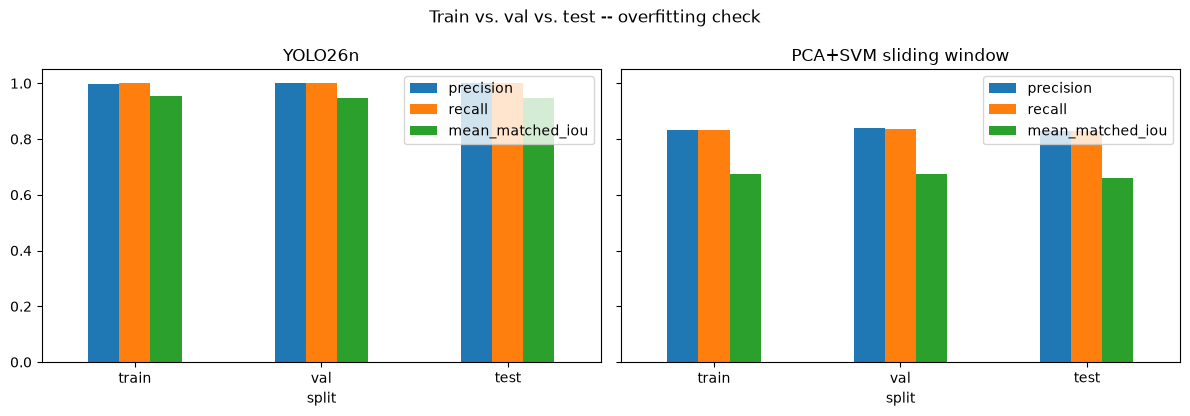

YOLO26n   train->test precision drop: -0.001
YOLO26n   train->test recall drop:    +0.000
PCA+SVM   train->test precision drop: +0.004
PCA+SVM   train->test recall drop:    +0.003


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
yolo_manual_df[["precision", "recall", "mean_matched_iou"]].plot.bar(ax=axes[0])
axes[0].set_title("YOLO26n"); axes[0].set_ylim(0, 1.05)
svm_manual_df[["precision", "recall", "mean_matched_iou"]].plot.bar(ax=axes[1])
axes[1].set_title("PCA+SVM sliding window"); axes[1].set_ylim(0, 1.05)
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Train vs. val vs. test -- overfitting check")
fig.tight_layout(); plt.show()

print(f"YOLO26n   train->test precision drop: {yolo_manual_df.loc['train','precision'] - yolo_manual_df.loc['test','precision']:+.3f}")
print(f"YOLO26n   train->test recall drop:    {yolo_manual_df.loc['train','recall'] - yolo_manual_df.loc['test','recall']:+.3f}")
print(f"PCA+SVM   train->test precision drop: {svm_manual_df.loc['train','precision'] - svm_manual_df.loc['test','precision']:+.3f}")
print(f"PCA+SVM   train->test recall drop:    {svm_manual_df.loc['train','recall'] - svm_manual_df.loc['test','recall']:+.3f}")